In [7]:
# 쓰레기 재활용 분류기 모델 + 전이학습 + 미세조정
# google drive에 저장된 waste dataset 읽어서 처리

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

DATASET_PATH = "/content/drive/MyDrive/garbage classification"

IMGSIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
  DATASET_PATH,
  validation_split=0.2,
  subset='training',
  seed=SEED,
  image_size=IMGSIZE,
  batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  DATASET_PATH,
  validation_split=0.2,
  subset='validation',
  seed=SEED,
  image_size=IMGSIZE,
  batch_size=BATCH_SIZE
)

print(train_ds.element_spec,' ', len(train_ds.file_paths))  #  2022
print(val_ds.element_spec,' ', len(val_ds.file_paths))      #   505

class_names = train_ds.class_names
print('class_names: ', class_names)   #  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']





Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))   2022
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))   505
class_names:  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [8]:
from prompt_toolkit.styles import base
from tensorflow._api.v2.data import AUTOTUNE
# 원래 validation dataset을 다시 validation + test dataset으로 나누기
# train / validation/ test 3개로 나누기 (8:1:1)
val_batchs = tf.data.experimental.cardinality(val_ds)   # cardinality : batch 갯수 세기(batch 기준)
test_ds = val_ds.take(val_batchs // 2)
val_ds = val_ds.skip(val_batchs // 2)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# 데이터 증강
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),  # 좌우 뒤집기
    layers.RandomRotation(0.1),       # 이미지 회전
    layers.RandomZoom(0.1),           # 이미지 확대
    layers.RandomContrast(0.1)        # 명암 변환
])

base_model = MobileNetV2(
    input_shape= (224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,    # 갯수를 늘린 것이 아니라 학습 시 이미지가 입력될 때 랜덤하게 변형이됨
    layers.Rescaling(1 / 127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(rate=0.3),
    layers.Dense(units=128, activation='relu'),
    layers.Dropout(rate=0.3),
    layers.Dense(units=len(class_names), activation='softmax')
])
print(model.summary())


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [11]:
from sklearn.utils import validation
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]

history_baseline = model.fit(
    train_ds,validation_data=val_ds, epochs=100, callbacks=callbacks
)

baseline_loss, baseline_acc = model.evaluate(test_ds)
print(f'baseline_ : loss: {baseline_loss:.4f}, acc: {baseline_acc:.4f}')

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 302s 5s/step - accuracy: 0.5964 - loss: 1.1010 - val_accuracy: 0.7470 - val_loss: 0.6269 - learning_rate: 0.0010
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.7438 - loss: 0.7048 - val_accuracy: 0.8032 - val_loss: 0.5687 - learning_rate: 0.0010
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - accuracy: 0.7908 - loss: 0.5658 - val_accuracy: 0.7912 - val_loss: 0.5623 - learning_rate: 0.0010
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.8091 - loss: 0.5284 - val_accuracy: 0.7791 - val_loss: 0.6111 - learning_rate: 0.0010
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.8210 - loss: 0.4965 - val_accuracy: 0.8394 - val_loss: 0.4785 - learning_rate: 0.0010
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.8254 - loss: 0.4598 - val_accuracy: 0.8313 - val_loss: 0.5355 - learning_rate: 0.0010
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.8516 - loss:

In [13]:
# Fine Tunning
base_model.trainable = True     # backbone unfreeze

for layer in base_model.layers[:-32]:
    layer.trainble = False

# fine tunning compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,validation_data=val_ds, epochs=100, callbacks=callbacks
)

finetune_loss, finetune_acc = model.evaluate(test_ds)
print(f'baseline_ : loss: {finetune_loss:.4f}, acc: {finetune_acc:.4f}')

model.save('garbage_classify.keras')

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 387ms/step - accuracy: 0.6741 - loss: 0.9018 - val_accuracy: 0.8755 - val_loss: 0.3519 - learning_rate: 1.0000e-05
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 345ms/step - accuracy: 0.7240 - loss: 0.7674 - val_accuracy: 0.8755 - val_loss: 0.4387 - learning_rate: 1.0000e-05
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 369ms/step - accuracy: 0.7681 - loss: 0.6284 - val_accuracy: 0.8835 - val_loss: 0.3832 - learning_rate: 1.0000e-05
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.7766 - loss: 0.6036
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 354ms/step - accuracy: 0.7799 - loss: 0.5876 - val_accuracy: 0.8554 - val_loss: 0.4154 - learning_rate: 1.0000e-05
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 314ms/step - accuracy: 0.7799 - loss: 0.5435 - val_accuracy: 0.8635 - val_loss: 0.3767 - learning_rate: 2.0000e-06
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 305ms/step - ac

In [ ]:
# 시각화
acc = (history_baseline.history['accuracy'] + history_finetune.history['accuracy'])
val_acc = (history_baseline.history['val_accuracy'] + history_finetune.history['val_accuracy'])
loss = (history_baseline.history['loss'] + history_finetune.history['loss'])
val_loss = (history_baseline.history['val_loss'] + history_finetune.history['val_loss'])

epochs_range = range(len(acc))
plt.figure(figsize=(14, 5))

# acc
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# loss

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Accuracy')
plt.plot(epochs_range, val_loss, label='Validation Accuracy')
plt.legend(loc='upper right')
plt.title('Training and Validation Accuracy')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


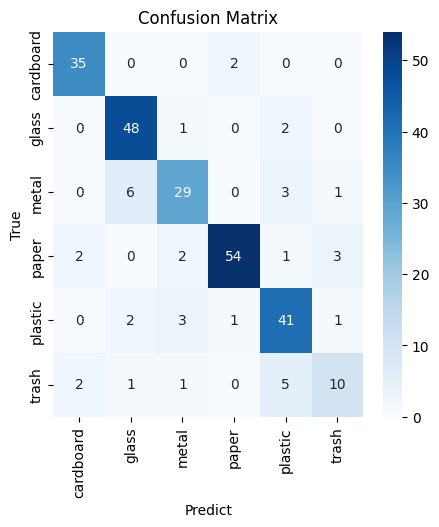

              precision    recall  f1-score   support

   cardboard       0.90      0.95      0.92        37
       glass       0.84      0.94      0.89        51
       metal       0.81      0.74      0.77        39
       paper       0.95      0.87      0.91        62
     plastic       0.79      0.85      0.82        48
       trash       0.67      0.53      0.59        19

    accuracy                           0.85       256
   macro avg       0.82      0.81      0.82       256
weighted avg       0.85      0.85      0.85       256



In [17]:
# 예측
y_true = []
y_pred = []

for images, labels in test_ds:
  predictions = model.predict(images)
  y_true.extend(labels.numpy())
  y_pred.extend(np.argmax(predictions, axis=1))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
# print(cm)
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predict')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [19]:
# 새로운 이미지를 분류 예측 - 여기부터는 새로운 파일이라 가정
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

model = tf.keras.models.load_model('garbage_classify.keras')

class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

def predict_garbageFunc(img_path):
  img = image.load_img(img_path, target_size=(224, 224))
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)


  predictions = model.predict(img_array)
  pred_index = np.argmax(predictions)
  pred_class = class_names[pred_index]
  confidence = np.max(predictions)

  print(f'예측 결과 : {pred_class}')
  print(f'신뢰도 : ', round(confidence * 100, 2), '%')
  return pred_class, confidence
predict_garbageFunc('myimage.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
예측 결과 : glass
신뢰도 :  62.74 %


('glass', np.float32(0.6273604))